In [ ]:
# ============================================================
# GuardAI — Full Dataset (Good & Bad Speech)
# Copy-paste into Google Colab — No API needed
# ============================================================

import pandas as pd
import json

# ============================================================
# DATASET
# ============================================================

data = [

    # ==================== SAFE / GOOD SPEECH ====================

    # Compliments & Kindness
    ("Thank you so much for your help today, I really appreciate it!", "SAFE", "compliment"),
    ("You did an absolutely wonderful job on that project!", "SAFE", "compliment"),
    ("I'm so proud of how far you've come, keep it up!", "SAFE", "compliment"),
    ("You are one of the kindest people I have ever met.", "SAFE", "compliment"),
    ("Great work! You really nailed it this time.", "SAFE", "compliment"),
    ("I love how passionate you are about this topic.", "SAFE", "compliment"),
    ("You always know exactly what to say to make people feel better.", "SAFE", "compliment"),
    ("Your presentation was outstanding, everyone was impressed.", "SAFE", "compliment"),
    ("I admire your dedication and hard work every single day.", "SAFE", "compliment"),
    ("You are so creative, this idea is brilliant!", "SAFE", "compliment"),

    # Support & Encouragement
    ("Don't give up, you are so close to reaching your goal!", "SAFE", "encouragement"),
    ("I believe in you, you can do this!", "SAFE", "encouragement"),
    ("Everyone makes mistakes, what matters is that you keep going.", "SAFE", "encouragement"),
    ("You are stronger than you think, hang in there.", "SAFE", "encouragement"),
    ("Things will get better, I promise. I'm here for you.", "SAFE", "encouragement"),
    ("You've overcome hard things before, you'll get through this too.", "SAFE", "encouragement"),
    ("Take your time, there is no rush. You've got this.", "SAFE", "encouragement"),
    ("I'm always here if you need someone to talk to.", "SAFE", "encouragement"),
    ("Your effort is inspiring, never stop trying.", "SAFE", "encouragement"),
    ("Believe in yourself as much as others believe in you.", "SAFE", "encouragement"),

    # Constructive Feedback
    ("I think there's room to improve here, but you're on the right track.", "SAFE", "feedback"),
    ("This is a good start. Maybe try adjusting the second paragraph.", "SAFE", "feedback"),
    ("I noticed a few errors, but overall this is solid work.", "SAFE", "feedback"),
    ("Have you considered approaching it from a different angle?", "SAFE", "feedback"),
    ("The idea is great, the execution just needs a little refining.", "SAFE", "feedback"),
    ("Your logic is sound, but the conclusion could be stronger.", "SAFE", "feedback"),
    ("I'd suggest revisiting this section to make it clearer.", "SAFE", "feedback"),
    ("Good effort! With a bit more practice this will be perfect.", "SAFE", "feedback"),
    ("You're nearly there, just a few tweaks needed.", "SAFE", "feedback"),
    ("This is much better than last time, well done!", "SAFE", "feedback"),

    # Neutral / Everyday Speech
    ("Can you please pass me the salt?", "SAFE", "neutral"),
    ("What time does the meeting start tomorrow?", "SAFE", "neutral"),
    ("I'm going to the grocery store, do you need anything?", "SAFE", "neutral"),
    ("The weather is really nice today, isn't it?", "SAFE", "neutral"),
    ("Let me know when you're free to catch up.", "SAFE", "neutral"),
    ("I just finished reading a really interesting book.", "SAFE", "neutral"),
    ("Could you help me understand this concept better?", "SAFE", "neutral"),
    ("I think we should schedule a meeting to discuss this.", "SAFE", "neutral"),
    ("The project deadline is next Friday.", "SAFE", "neutral"),
    ("I'll get back to you as soon as possible.", "SAFE", "neutral"),

    # Disagreement (Respectful)
    ("I respectfully disagree with your point of view on this matter.", "SAFE", "disagreement"),
    ("I see things differently, but I understand where you're coming from.", "SAFE", "disagreement"),
    ("That's an interesting perspective, though I have a different opinion.", "SAFE", "disagreement"),
    ("I don't think that's quite right, but let me explain my reasoning.", "SAFE", "disagreement"),
    ("We may not agree on this, but I respect your stance.", "SAFE", "disagreement"),
    ("I think there are some flaws in that argument, here's why.", "SAFE", "disagreement"),
    ("Could we revisit this? I'm not sure I agree with the conclusion.", "SAFE", "disagreement"),
    ("I appreciate your input but I have a different take on this.", "SAFE", "disagreement"),
    ("That's not how I see it, but I'm open to discussing it further.", "SAFE", "disagreement"),
    ("We can agree to disagree on this one.", "SAFE", "disagreement"),

    # Apologies
    ("I'm truly sorry for what I said, it was wrong of me.", "SAFE", "apology"),
    ("Please forgive me, I didn't mean to hurt you.", "SAFE", "apology"),
    ("I apologize sincerely, that was out of line.", "SAFE", "apology"),
    ("I regret my actions and I take full responsibility.", "SAFE", "apology"),
    ("I'm sorry, I should have thought before speaking.", "SAFE", "apology"),

    # ==================== MILD / BORDERLINE SPEECH ====================

    # Frustration (Not Targeted)
    ("Ugh, this is so frustrating, nothing is working!", "MILD", "frustration"),
    ("I can't believe how long this is taking, so annoying.", "MILD", "frustration"),
    ("This is honestly ridiculous, what a waste of time.", "MILD", "frustration"),
    ("I'm sick and tired of dealing with this every single day.", "MILD", "frustration"),
    ("This customer service is absolutely terrible.", "MILD", "frustration"),
    ("I've had it with all these stupid technical issues.", "MILD", "frustration"),
    ("What the heck is going on with this system?", "MILD", "frustration"),
    ("This is a complete disaster, nothing went as planned.", "MILD", "frustration"),
    ("I'm so done with this, it's driving me crazy.", "MILD", "frustration"),
    ("This is beyond annoying, I just want it to work.", "MILD", "frustration"),

    # Mild Insults / Rude Comments
    ("You're being really dumb about this, just think for a second.", "MILD", "mild_insult"),
    ("That was a pretty stupid thing to do, don't you think?", "MILD", "mild_insult"),
    ("You're acting like a complete jerk right now.", "MILD", "mild_insult"),
    ("Could you stop being so annoying for once?", "MILD", "mild_insult"),
    ("You're so full of yourself, it's exhausting.", "MILD", "mild_insult"),
    ("Honestly, you're kind of a pain to deal with sometimes.", "MILD", "mild_insult"),
    ("Stop being such a crybaby and toughen up.", "MILD", "mild_insult"),
    ("You never listen, it's so infuriating.", "MILD", "mild_insult"),
    ("That was a dumb idea, I'm not going to sugarcoat it.", "MILD", "mild_insult"),
    ("You're so lazy, you never put in any effort.", "MILD", "mild_insult"),

    # Passive Aggression
    ("Fine. Do whatever you want, I don't care anymore.", "MILD", "passive_aggressive"),
    ("Oh sure, because you always know best, don't you.", "MILD", "passive_aggressive"),
    ("I guess some people just don't care about others' feelings.", "MILD", "passive_aggressive"),
    ("Whatever, it's not like my opinion matters anyway.", "MILD", "passive_aggressive"),
    ("Must be nice to never have to deal with consequences.", "MILD", "passive_aggressive"),
    ("I'm fine. Everything's fine. It's all absolutely fine.", "MILD", "passive_aggressive"),
    ("No no, don't mind me, I'll just do everything myself.", "MILD", "passive_aggressive"),
    ("Thanks for the heads up... eventually.", "MILD", "passive_aggressive"),
    ("Oh I didn't realize my feelings were so inconvenient for you.", "MILD", "passive_aggressive"),
    ("I'll just sit here quietly and be invisible, shall I?", "MILD", "passive_aggressive"),

    # ==================== ABUSIVE SPEECH ====================

    # Direct Insults & Name Calling
    ("You are a complete and utter idiot, how are you even functioning?", "ABUSIVE", "insult"),
    ("You are the most pathetic loser I have ever had the misfortune of meeting.", "ABUSIVE", "insult"),
    ("What a worthless piece of garbage you are.", "ABUSIVE", "insult"),
    ("You are absolutely disgusting, no one wants you around.", "ABUSIVE", "insult"),
    ("You are brain dead, there is no other explanation for this.", "ABUSIVE", "insult"),
    ("You are a failure at everything you do, it's actually impressive.", "ABUSIVE", "insult"),
    ("Nobody likes you, you are insufferable and repulsive.", "ABUSIVE", "insult"),
    ("You are the worst person I've ever met, bar none.", "ABUSIVE", "insult"),
    ("You are a coward and a liar and everyone knows it.", "ABUSIVE", "insult"),
    ("You are utterly useless, a waste of space and air.", "ABUSIVE", "insult"),

    # Profanity & Aggressive Language
    ("Go f*** yourself, I'm done with your garbage.", "ABUSIVE", "profanity"),
    ("You piece of s***, you have no idea what you're talking about.", "ABUSIVE", "profanity"),
    ("Shut your stupid mouth before I shut it for you.", "ABUSIVE", "profanity"),
    ("You're a dumb b**** who doesn't know anything.", "ABUSIVE", "profanity"),
    ("Get the hell out of my sight, you absolute moron.", "ABUSIVE", "profanity"),
    ("You're a complete a**hole and everyone hates you.", "ABUSIVE", "profanity"),
    ("What the f*** is wrong with you, are you insane?", "ABUSIVE", "profanity"),
    ("Go to hell, you worthless piece of trash.", "ABUSIVE", "profanity"),
    ("You're a lying sack of crap and nobody believes you.", "ABUSIVE", "profanity"),
    ("I can't stand you, you're the worst kind of scum.", "ABUSIVE", "profanity"),

    # Harassment
    ("I will ruin your life and make sure everyone knows what you did.", "ABUSIVE", "harassment"),
    ("You better watch yourself, I know people who can make things difficult for you.", "ABUSIVE", "harassment"),
    ("I'm going to make sure you lose your job, your reputation, everything.", "ABUSIVE", "harassment"),
    ("Nobody wants you here, why don't you just disappear forever.", "ABUSIVE", "harassment"),
    ("I'll expose you for the fraud you are, just you wait.", "ABUSIVE", "harassment"),
    ("Keep ignoring me and see what happens to you.", "ABUSIVE", "harassment"),
    ("You think you can just block me? I'll find other ways to reach you.", "ABUSIVE", "harassment"),
    ("You are going to regret every single thing you've done to me.", "ABUSIVE", "harassment"),
    ("I'll make sure your family knows what kind of person you really are.", "ABUSIVE", "harassment"),
    ("I'm not going to stop until you're completely destroyed.", "ABUSIVE", "harassment"),

    # Threats
    ("Watch your back, because I'm coming for you.", "ABUSIVE", "threat"),
    ("You better do what I say or you'll regret it.", "ABUSIVE", "threat"),
    ("I swear I will hurt you if you cross me again.", "ABUSIVE", "threat"),
    ("You're dead to me and soon you'll be dead to everyone else.", "ABUSIVE", "threat"),
    ("Keep talking and see what I do to you.", "ABUSIVE", "threat"),
    ("I'll find you no matter where you hide.", "ABUSIVE", "threat"),
    ("One more word and you'll be sorry.", "ABUSIVE", "threat"),
    ("I know where you live and I'm not afraid to show up.", "ABUSIVE", "threat"),
    ("You'll pay for this, I promise you that.", "ABUSIVE", "threat"),
    ("This isn't a warning, this is a promise — you're finished.", "ABUSIVE", "threat"),

    # Bullying
    ("You are such a loser, everyone laughs at you behind your back.", "ABUSIVE", "bullying"),
    ("No wonder you have no friends, you're impossible to like.", "ABUSIVE", "bullying"),
    ("You should just give up, you'll never be good enough.", "ABUSIVE", "bullying"),
    ("Everyone thinks you're a joke, they just don't say it to your face.", "ABUSIVE", "bullying"),
    ("You're so ugly and stupid, it's no surprise people avoid you.", "ABUSIVE", "bullying"),
    ("Kill yourself, no one would even notice you were gone.", "ABUSIVE", "bullying"),
    ("You are worthless and the world would be better without you.", "ABUSIVE", "bullying"),
    ("Just quit already, you were never meant to succeed.", "ABUSIVE", "bullying"),
    ("You cry about everything like a little baby, it's embarrassing.", "ABUSIVE", "bullying"),
    ("Nobody wants you here, do everyone a favor and leave.", "ABUSIVE", "bullying"),

    # Hate Speech & Discrimination
    ("People like you don't belong in this country, go back to where you came from.", "ABUSIVE", "hate_speech"),
    ("Your kind has always been the root of every problem in society.", "ABUSIVE", "hate_speech"),
    ("Women are too emotional to ever be in positions of power.", "ABUSIVE", "hate_speech"),
    ("Disabled people are just a burden on the rest of society.", "ABUSIVE", "hate_speech"),
    ("Gay people are an abomination and should be ashamed of themselves.", "ABUSIVE", "hate_speech"),
    ("People of that religion are all terrorists, simple as that.", "ABUSIVE", "hate_speech"),
    ("That entire race is inferior and history has proven it.", "ABUSIVE", "hate_speech"),
    ("Immigrants are stealing jobs and destroying our culture.", "ABUSIVE", "hate_speech"),
    ("Trans people are mentally ill and should not be allowed in public.", "ABUSIVE", "hate_speech"),
    ("Poor people are poor because they're lazy and deserve it.", "ABUSIVE", "hate_speech"),

    # Online Toxic Comments
    ("This is the dumbest post I've ever seen, delete your account.", "ABUSIVE", "toxic_online"),
    ("No one asked for your opinion, stay in your lane loser.", "ABUSIVE", "toxic_online"),
    ("Ratio. You're irrelevant and your take is garbage.", "ABUSIVE", "toxic_online"),
    ("You're so cringe, please log off and never come back.", "ABUSIVE", "toxic_online"),
    ("This person is the reason comment sections should be banned.", "ABUSIVE", "toxic_online"),
    ("Imagine being this stupid and still posting publicly.", "ABUSIVE", "toxic_online"),
    ("Touch grass, you pathetic basement-dwelling loser.", "ABUSIVE", "toxic_online"),
    ("Your page is a joke, just like you.", "ABUSIVE", "toxic_online"),
    ("I can't believe someone as dumb as you has internet access.", "ABUSIVE", "toxic_online"),
    ("Go back to living under your rock, nobody wants your input.", "ABUSIVE", "toxic_online"),

]

# ============================================================
# Convert to DataFrame
# ============================================================

df = pd.DataFrame(data, columns=["text", "label", "subcategory"])

print(f"✅ Dataset loaded: {len(df)} samples")
print(f"\n📊 Label distribution:")
print(df["label"].value_counts().to_string())
print(f"\n📁 Subcategory breakdown:")
print(df["subcategory"].value_counts().to_string())

# ============================================================
# Save as CSV
# ============================================================

df.to_csv("abuse_detection_dataset.csv", index=False)
print("\n💾 Saved to: abuse_detection_dataset.csv")

# ============================================================
# Save as JSON
# ============================================================

records = df.to_dict(orient="records")
with open("abuse_detection_dataset.json", "w") as f:
    json.dump(records, f, indent=2)
print("💾 Saved to: abuse_detection_dataset.json")

# ============================================================
# Preview samples from each label
# ============================================================

print("\n" + "="*60)
print("SAMPLE PREVIEW")
print("="*60)

for label in ["SAFE", "MILD", "ABUSIVE"]:
    print(f"\n--- {label} ---")
    samples = df[df["label"] == label].sample(3, random_state=42)
    for _, row in samples.iterrows():
        print(f"  [{row['subcategory']}] {row['text']}")

# ============================================================
# Download files in Colab
# ============================================================

from google.colab import files
files.download("abuse_detection_dataset.csv")
files.download("abuse_detection_dataset.json")

print("\n✅ Done! Both files downloaded.")

✅ Dataset loaded: 155 samples

📊 Label distribution:
label
ABUSIVE    70
SAFE       55
MILD       30

📁 Subcategory breakdown:
subcategory
compliment            10
encouragement         10
feedback              10
neutral               10
disagreement          10
frustration           10
mild_insult           10
passive_aggressive    10
threat                10
insult                10
profanity             10
harassment            10
hate_speech           10
bullying              10
toxic_online          10
apology                5

💾 Saved to: abuse_detection_dataset.csv
💾 Saved to: abuse_detection_dataset.json

SAMPLE PREVIEW

--- SAFE ---
  [neutral] What time does the meeting start tomorrow?
  [compliment] I love how passionate you are about this topic.
  [neutral] I'm going to the grocery store, do you need anything?

--- MILD ---
  [passive_aggressive] Thanks for the heads up... eventually.
  [mild_insult] Honestly, you're kind of a pain to deal with sometimes.
  [passive_aggres

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Done! Both files downloaded.


       GUARDAI — ABUSE LANGUAGE DETECTOR PIPELINE

✅ Dataset loaded: 155 samples

📊 Label Distribution:
label
ABUSIVE    70
SAFE       55
MILD       30


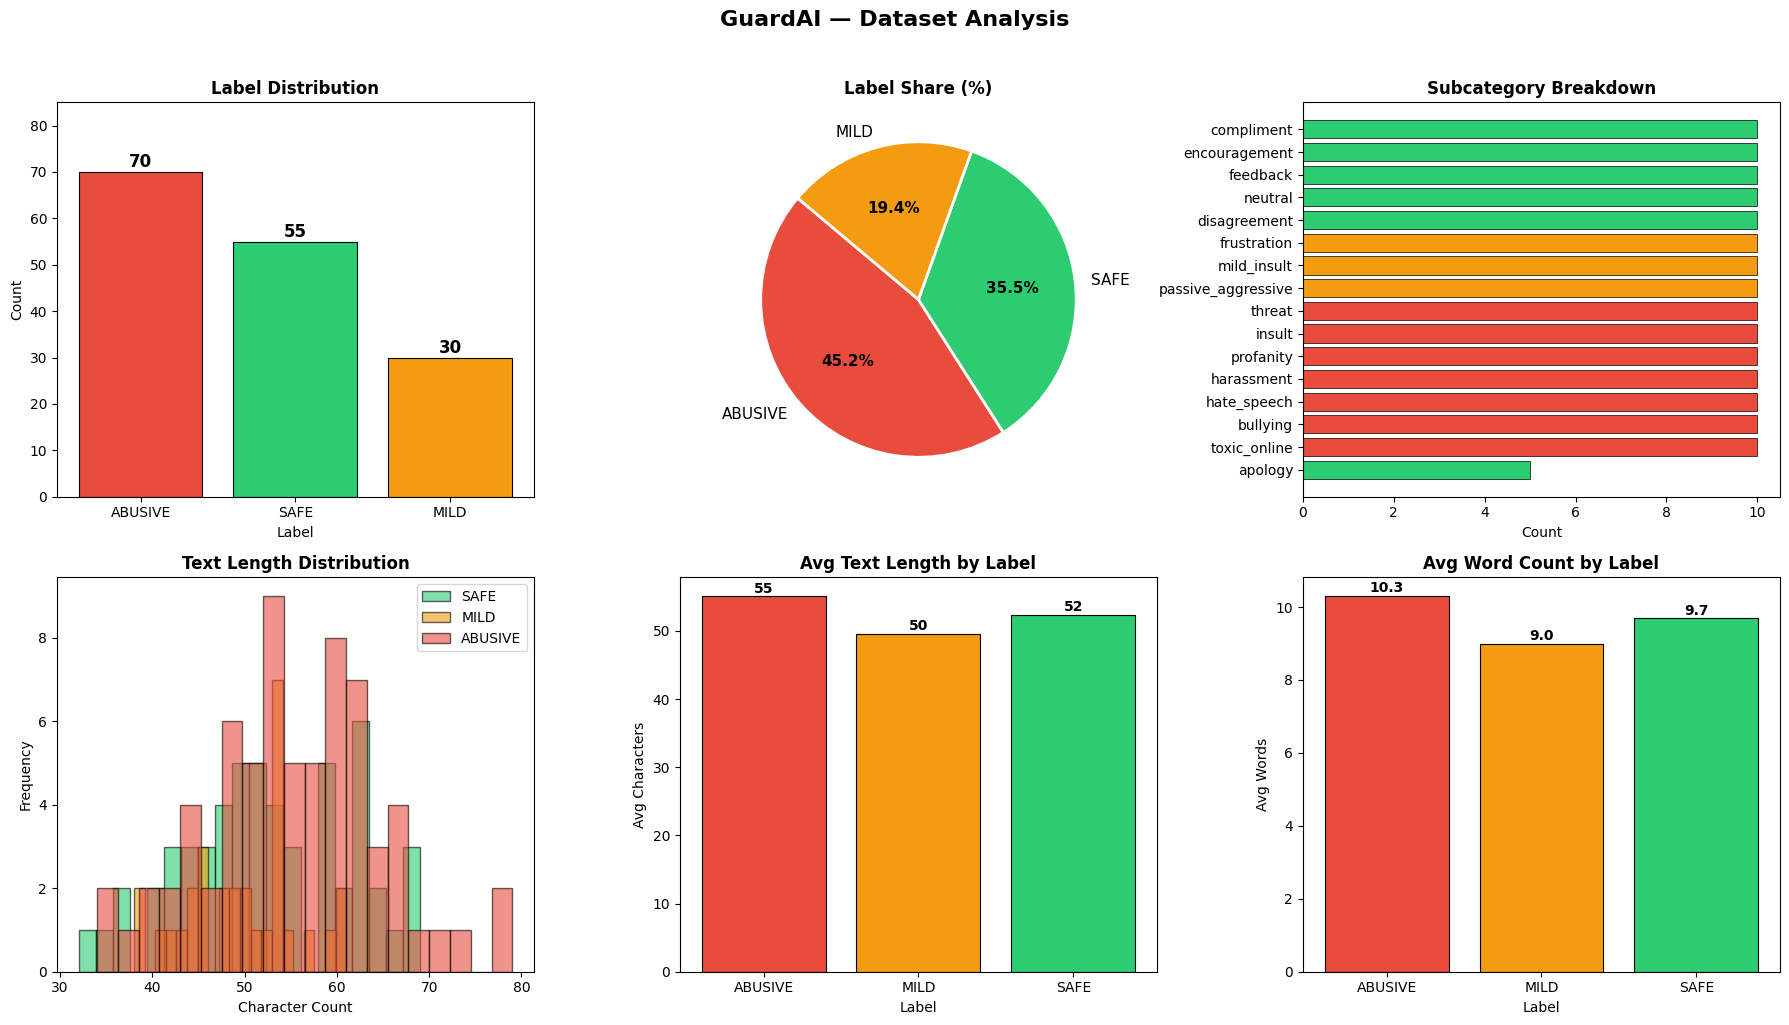


✅ Dataset analysis chart saved.


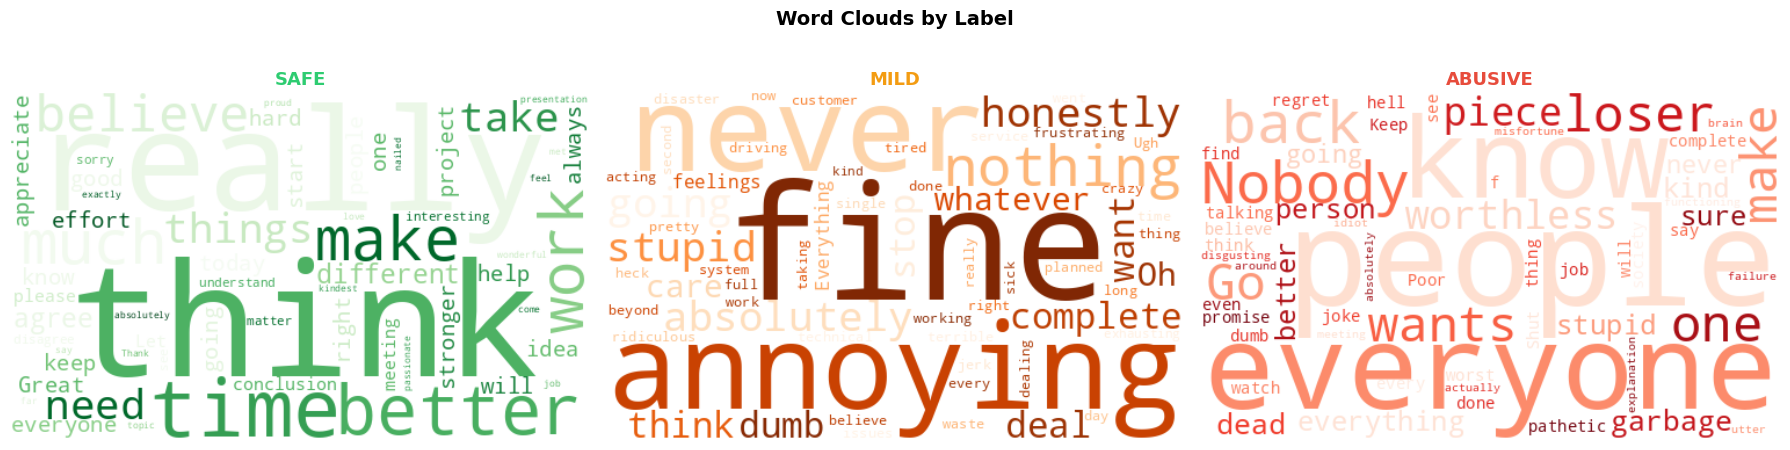

✅ Word clouds saved.

  TRAINING MODEL

📦 Training samples : 124
🧪 Testing samples  : 31

✅ Model trained!
🎯 Accuracy: 61.3%

📋 Classification Report:
              precision    recall  f1-score   support

     ABUSIVE       0.61      0.79      0.69        14
        MILD       0.60      0.50      0.55         6
        SAFE       0.62      0.45      0.53        11

    accuracy                           0.61        31
   macro avg       0.61      0.58      0.59        31
weighted avg       0.61      0.61      0.60        31



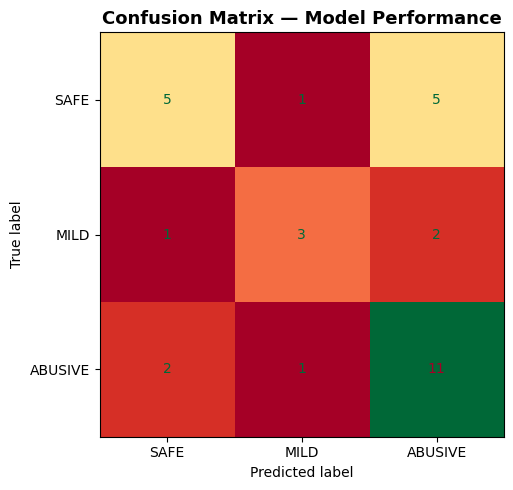

✅ Confusion matrix saved.

  SAMPLE TESTS

📝 INPUT : Thank you so much, you really helped me out today!

✅  VERDICT    : SAFE
📊  CONFIDENCE : 46.3%

📈  SCORE BREAKDOWN:
   🟢 SAFE     █████████░░░░░░░░░░░ 46.3%
   🟡 MILD     ████░░░░░░░░░░░░░░░░ 24.7%
   🔴 ABUSIVE  █████░░░░░░░░░░░░░░░ 29.1%
✅ Message is safe. No issues detected.


📝 INPUT : This is honestly so frustrating and annoying.

⚠️  VERDICT    : MILD
📊  CONFIDENCE : 58.3%

📈  SCORE BREAKDOWN:
   🟢 SAFE     ████░░░░░░░░░░░░░░░░ 21.4%
   🟡 MILD     ███████████░░░░░░░░░ 58.3%
   🔴 ABUSIVE  ████░░░░░░░░░░░░░░░░ 20.3%
⚠️  WARNING: This message has a mildly problematic tone.
   Consider rephrasing to be more respectful.


🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫

   ❌  ERROR: ABUSIVE CONTENT DETECTED

🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫🚫

┌─────────────────────────────────────────────┐
│           ⛔  INPUT BLOCKED                  │
│                                             │
│  Your message contains abusive language     │
│  and has been flagge

In [ ]:
# ============================================================
# GuardAI — Full Pipeline: Analyze Dataset + Live Detector
# ============================================================

!pip install pandas scikit-learn matplotlib seaborn wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from wordcloud import WordCloud

# ============================================================
# STEP 1 — Load Dataset
# ============================================================

df = pd.read_csv("abuse_detection_dataset.csv")

print("=" * 60)
print("       GUARDAI — ABUSE LANGUAGE DETECTOR PIPELINE")
print("=" * 60)
print(f"\n✅ Dataset loaded: {len(df)} samples")
print(f"\n📊 Label Distribution:")
print(df["label"].value_counts().to_string())

# ============================================================
# STEP 2 — Dataset Analysis & Visualizations
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("GuardAI — Dataset Analysis", fontsize=16, fontweight="bold", y=1.02)

# --- Plot 1: Label Distribution (Bar) ---
ax1 = axes[0, 0]
counts = df["label"].value_counts()
colors = {"SAFE": "#2ecc71", "MILD": "#f39c12", "ABUSIVE": "#e74c3c"}
bars = ax1.bar(counts.index, counts.values,
               color=[colors[l] for l in counts.index],
               edgecolor="black", linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha="center", fontweight="bold", fontsize=12)
ax1.set_title("Label Distribution", fontweight="bold")
ax1.set_xlabel("Label")
ax1.set_ylabel("Count")
ax1.set_ylim(0, max(counts.values) + 15)

# --- Plot 2: Label Distribution (Pie) ---
ax2 = axes[0, 1]
pie_colors = [colors[l] for l in counts.index]
wedges, texts, autotexts = ax2.pie(
    counts.values, labels=counts.index, autopct="%1.1f%%",
    colors=pie_colors, startangle=140,
    textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontweight("bold")
ax2.set_title("Label Share (%)", fontweight="bold")

# --- Plot 3: Subcategory Breakdown ---
ax3 = axes[0, 2]
sub_counts = df["subcategory"].value_counts()
sub_colors = []
for sub in sub_counts.index:
    label = df[df["subcategory"] == sub]["label"].iloc[0]
    sub_colors.append(colors[label])
bars3 = ax3.barh(sub_counts.index, sub_counts.values,
                  color=sub_colors, edgecolor="black", linewidth=0.5)
ax3.set_title("Subcategory Breakdown", fontweight="bold")
ax3.set_xlabel("Count")
ax3.invert_yaxis()

# --- Plot 4: Text Length Distribution ---
ax4 = axes[1, 0]
df["text_length"] = df["text"].apply(len)
for label, color in colors.items():
    subset = df[df["label"] == label]["text_length"]
    ax4.hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor="black")
ax4.set_title("Text Length Distribution", fontweight="bold")
ax4.set_xlabel("Character Count")
ax4.set_ylabel("Frequency")
ax4.legend()

# --- Plot 5: Average Text Length by Label ---
ax5 = axes[1, 1]
avg_len = df.groupby("label")["text_length"].mean()
bars5 = ax5.bar(avg_len.index, avg_len.values,
                color=[colors[l] for l in avg_len.index],
                edgecolor="black", linewidth=0.8)
for bar, val in zip(bars5, avg_len.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.0f}", ha="center", fontweight="bold")
ax5.set_title("Avg Text Length by Label", fontweight="bold")
ax5.set_xlabel("Label")
ax5.set_ylabel("Avg Characters")

# --- Plot 6: Word Count Distribution ---
ax6 = axes[1, 2]
df["word_count"] = df["text"].apply(lambda x: len(x.split()))
word_avg = df.groupby("label")["word_count"].mean()
bars6 = ax6.bar(word_avg.index, word_avg.values,
                color=[colors[l] for l in word_avg.index],
                edgecolor="black", linewidth=0.8)
for bar, val in zip(bars6, word_avg.values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", fontweight="bold")
ax6.set_title("Avg Word Count by Label", fontweight="bold")
ax6.set_xlabel("Label")
ax6.set_ylabel("Avg Words")

plt.tight_layout()
plt.savefig("dataset_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n Dataset analysis chart saved.")

# ============================================================
# STEP 3 — Word Clouds per Label
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Word Clouds by Label", fontsize=14, fontweight="bold")

wc_colors = {"SAFE": "Greens", "MILD": "Oranges", "ABUSIVE": "Reds"}

for ax, label in zip(axes, ["SAFE", "MILD", "ABUSIVE"]):
    text_blob = " ".join(df[df["label"] == label]["text"].tolist())
    wc = WordCloud(width=500, height=300, background_color="white",
                   colormap=wc_colors[label], max_words=60).generate(text_blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{label}", fontweight="bold", fontsize=13,
                 color=colors[label])
    ax.axis("off")

plt.tight_layout()
plt.savefig("wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Word clouds saved.")

# ============================================================
# STEP 4 — Train ML Model
# ============================================================

print("\n" + "="*60)
print("  TRAINING MODEL")
print("="*60)

X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📦 Training samples : {len(X_train)}")
print(f"🧪 Testing samples  : {len(X_test)}")

# Build pipeline
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True,
        min_df=1
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight="balanced",
        random_state=42
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel trained!")
print(f" Accuracy: {accuracy * 100:.1f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================================
# STEP 5 — Confusion Matrix
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred, labels=["SAFE", "MILD", "ABUSIVE"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["SAFE", "MILD", "ABUSIVE"])
disp.plot(ax=ax, colorbar=False, cmap="RdYlGn")
ax.set_title("Confusion Matrix — Model Performance", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Confusion matrix saved.")

# ============================================================
# STEP 6 — Prediction Function with Error on Abuse
# ============================================================

def analyze_text(text):
    """
    Analyzes text and returns verdict.
    Raises ValueError with full details if ABUSIVE.
    """
    if not text or not text.strip():
        raise ValueError("⚠️  Input cannot be empty.")

    label = model.predict([text])[0]
    probs = model.predict_proba([text])[0]
    classes = model.classes_
    prob_dict = dict(zip(classes, probs))

    confidence = max(probs) * 100
    icons = {"SAFE": "", "MILD": "", "ABUSIVE": ""}

    result = {
        "label"     : label,
        "confidence": round(confidence, 1),
        "scores"    : {k: round(v * 100, 1) for k, v in prob_dict.items()}
    }

    return result


def print_analysis(text, result):
    icons = {"SAFE": "", "MILD": "", "ABUSIVE": ""}
    bar_icons = {"SAFE": "", "MILD": "", "ABUSIVE": ""}

    print("\n" + "="*60)
    print(f"INPUT : {text[:70]}{'...' if len(text) > 70 else ''}")
    print("="*60)
    print(f"\n{icons[result['label']]}  VERDICT    : {result['label']}")
    print(f"CONFIDENCE : {result['confidence']}%")
    print(f"\n SCORE BREAKDOWN:")
    for label in ["SAFE", "MILD", "ABUSIVE"]:
        score = result["scores"].get(label, 0)
        bar = "" * int(score // 5) + "░" * (20 - int(score // 5))
        print(f"   {bar_icons[label]} {label:<8} {bar} {score}%")
    print("="*60)


def check_input(text):
    """
    Main entry point.
    Prints result OR raises a visible ERROR for abusive content.
    """
    result = analyze_text(text)

    if result["label"] == "ABUSIVE":
        print("\n" + "" * 30)
        print("\n    ERROR: ABUSIVE CONTENT DETECTED")
        print("\n" + "" * 30)
        print(f"""
┌─────────────────────────────────────────────┐
│           INPUT BLOCKED                  │
│                                             │
│  Your message contains abusive language     │
│  and has been flagged by GuardAI.           │
│                                             │
│  Confidence  : {result['confidence']}%                      │
│  Category    : ABUSIVE                      │
│                                             │
│  Please rephrase your message respectfully. │
└─────────────────────────────────────────────┘
""")
        print(f" Detection Scores:")
        for label in ["SAFE", "MILD", "ABUSIVE"]:
            score = result["scores"].get(label, 0)
            bar = "" * int(score // 5) + "" * (20 - int(score // 5))
            icon = "" if label == "SAFE" else "" if label == "MILD" else ""
            print(f"   {icon} {label:<8} {bar} {score}%")

        raise ValueError(f"\n ABUSIVE content detected ({result['confidence']}% confidence). Input rejected.")

    elif result["label"] == "MILD":
        print_analysis(text, result)
        print("  WARNING: This message has a mildly problematic tone.")
        print("   Consider rephrasing to be more respectful.\n")

    else:
        print_analysis(text, result)
        print("Message is safe. No issues detected.\n")

    return result

# ============================================================
# STEP 7 — Test on sample inputs
# ============================================================

print("\n" + "="*60)
print("  SAMPLE TESTS")
print("="*60)

test_inputs = [
    "Thank you so much, you really helped me out today!",
    "This is honestly so frustrating and annoying.",
    "You are a worthless piece of garbage, nobody likes you.",
    "I believe in you, keep going!",
    "Kill yourself, no one would even notice.",
    "Could you please review my work and give feedback?",
]

for text in test_inputs:
    try:
        check_input(text)
    except ValueError as e:
        print(f"   SYSTEM: {e}\n")

# ============================================================
# STEP 8 — Interactive Live Detector
# ============================================================

print("\n" + "="*60)
print("    LIVE DETECTOR — TYPE YOUR MESSAGE")
print("  Type 'quit' to exit")
print("="*60 + "\n")

while True:
    try:
        user_input = input("You: ").strip()

        if user_input.lower() in ("quit", "exit", "q"):
            print("\n GuardAI session ended. Stay respectful out there!")
            break

        if not user_input:
            print("  Please enter some text.\n")
            continue

        check_input(user_input)

    except ValueError as e:
        print(f"\n   SYSTEM MESSAGE: {e}\n")
        print("   Please try again with respectful language.\n")
    except KeyboardInterrupt:
        print("\n\n👋Session interrupted. Goodbye!")
        break